## Import

In [1]:
import gym_snakegame
import gymnasium as gym
import numpy as np
import torch.nn as nn
import torch
import gym_snakegame
from gym_snakegame.wrappers import RewardConverter, SnakeActionMask
from gymnasium.wrappers import DtypeObservation, TransformObservation, TransformReward, ReshapeObservation#, RecordVideo
from gymnasium.spaces import Box
from torch.distributions.categorical import Categorical
import matplotlib.pyplot as plt

## Definizione classi necessarie per i test

In [2]:
class CategoricalMasked(Categorical):
    def __init__(self, probs=None, logits=None, validate_args=None, masks=[]):
        self.masks = masks
        if len(self.masks) == 0:
            super(CategoricalMasked, self).__init__(probs, logits, validate_args)
        else:
            self.masks = masks.type(torch.BoolTensor).to(device)
            logits = torch.where(self.masks, logits, torch.tensor(-1e8).to(device))
            super(CategoricalMasked, self).__init__(probs, logits, validate_args)

    def entropy(self):
        if len(self.masks) == 0:
            return super(CategoricalMasked, self).entropy()
        p_log_p = self.logits * self.probs
        p_log_p = torch.where(self.masks, p_log_p, torch.tensor(0.0).to(device))
        return -p_log_p.sum(-1)


class Agent(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(n_channel, 32, 3),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 6 * 6, 1024),
            nn.ReLU(),
        )
        self.actor = nn.Linear(1024, env.action_space.n)
        self.critic = nn.Linear(1024, 1)

    def get_action(self, x, invalid_action_mask=None):
        hidden = self.network(x)
        logits = self.actor(hidden)
        probs = CategoricalMasked(logits=logits)#, masks=invalid_action_mask)
        action = probs.sample()
        return action


n_channel = 4
board_size = 12
model_path = (
    "cleanrl_ppo_v2_s12_240115_1705274806.pt"
)

## Test dell'agente in render mode "human"

In [3]:
n_episode = 3
env = gym.make("gym_snakegame/SnakeGame-v0", board_size=board_size, n_channel=4, render_mode=None)
#env = RecordVideo(env, ".", episode_trigger=lambda x: True, name_prefix="episode")
env = SnakeActionMask(env)
env = DtypeObservation(env, np.float32)
env = TransformObservation(
    env, lambda obs: obs / env.unwrapped.ITEM, Box(0, 1, (n_channel, board_size, board_size), dtype=np.float32)
)
env = ReshapeObservation(env, (1, n_channel, board_size, board_size))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
agent = Agent().to(device)
agent.load_state_dict(torch.load(model_path,map_location=torch.device('cuda')))

with torch.inference_mode():
    observation, info = env.reset()
    while n_episode > 0:
        invalid_action_mask = torch.Tensor(info["action_mask"]).to(device)
        action = agent.get_action(torch.Tensor(observation).to(device))#, invalid_action_mask=invalid_action_mask)
        observation, reward, terminated, truncated, info = env.step(action)
        if terminated or truncated:
            n_episode -= 1
            if n_episode > 0:
                obs, info = env.reset()
env.close()

## Test dell'agente senza rendering

In [4]:
n_episode = 1000
env = gym.make("gym_snakegame/SnakeGame-v0", board_size=board_size, n_channel=4, render_mode=None)
#env = RecordVideo(env, ".", episode_trigger=lambda x: True, name_prefix="episode")
env = SnakeActionMask(env)
env = DtypeObservation(env, np.float32)
env = TransformObservation(
    env, lambda obs: obs / env.unwrapped.ITEM, Box(0, 1, (n_channel, board_size, board_size), dtype=np.float32)
)
env = ReshapeObservation(env, (1, n_channel, board_size, board_size))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
agent = Agent().to(device)
agent.load_state_dict(torch.load(model_path,map_location=torch.device('cuda')))

# array per salvataggio dei return dei singoli episodi
returns = np.empty(n_episode)
score = 0

with torch.inference_mode():
    observation, info = env.reset()
    while n_episode > 0:
        invalid_action_mask = torch.Tensor(info["action_mask"]).to(device)
        action = agent.get_action(torch.Tensor(observation).to(device))#, invalid_action_mask=invalid_action_mask)
        observation, reward, terminated, truncated, info = env.step(action)
        score += reward # incremento dello score
        if terminated or truncated:
            if n_episode%50 == 0 : print("Terminato episodio: "+str(n_episode))
            #print("Terminato episodio: "+str(n_episode))
            returns[n_episode-1] = score # salvataggio dello score ottenuto sull'array returns
            score = 0 # azzeramento score per episodio successivo
            n_episode -= 1
            if n_episode > 0:
                obs, info = env.reset()
env.close()

Terminato episodio: 1000
Terminato episodio: 999
Terminato episodio: 998
Terminato episodio: 997
Terminato episodio: 996
Terminato episodio: 995
Terminato episodio: 994
Terminato episodio: 993
Terminato episodio: 992
Terminato episodio: 991
Terminato episodio: 990
Terminato episodio: 989
Terminato episodio: 988
Terminato episodio: 987
Terminato episodio: 986
Terminato episodio: 985
Terminato episodio: 984
Terminato episodio: 983
Terminato episodio: 982
Terminato episodio: 981
Terminato episodio: 980
Terminato episodio: 979
Terminato episodio: 978
Terminato episodio: 977
Terminato episodio: 976
Terminato episodio: 975
Terminato episodio: 974
Terminato episodio: 973
Terminato episodio: 972
Terminato episodio: 971
Terminato episodio: 970
Terminato episodio: 969
Terminato episodio: 968
Terminato episodio: 967
Terminato episodio: 966
Terminato episodio: 965
Terminato episodio: 964
Terminato episodio: 963
Terminato episodio: 962
Terminato episodio: 961
Terminato episodio: 960
Terminato episo

## Plot dell'istogramma degli score ottenuti

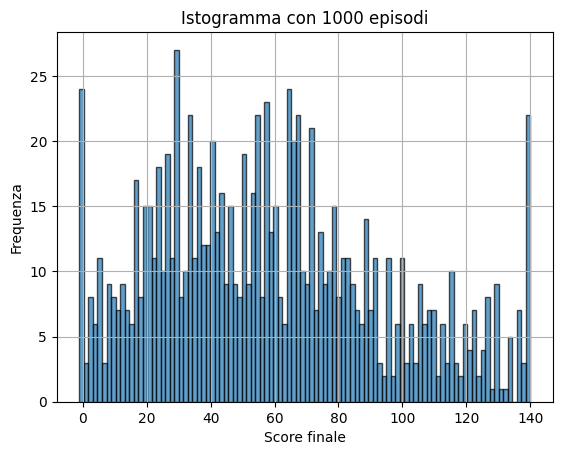

In [12]:
plt.hist(returns, bins=100, alpha=0.7, edgecolor="black")
plt.xlabel("Score finale")
plt.ylabel("Frequenza")
plt.title(f"Istogramma con 1000 episodi")
plt.grid(True)
plt.show()

In [11]:
print("Valor medio dei return: "+str(np.mean(returns)))
print("Valore minimo dei return: "+str(np.min(returns)))
print("Valore massimo dei return: "+str(np.max(returns)))

Valor medio dei return: 58.965
Valore minimo dei return: -1.0
Valore massimo dei return: 140.0
